# How to read data from database

In [1]:
# you need to establish/create your SQL connection
# or you need to define a connection engine to your database
# then you run SQL query so that we get data into some dataframe

In [3]:
import sqlite3

In [5]:
# Opens a connection to the SQLite database file database.
import zipfile
import os
import sqlite3

# Specify the path to the zip file and the SQLite file inside it
zip_file_path = r'D:\Resources.zip'
sqlite_file_name = 'zomato_rawdata.sqlite'
extracted_file_path = r'D:\extracted_sqlite'  # Folder to extract the file to

# Extract the SQLite file from the zip
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extract(sqlite_file_name, extracted_file_path)

# Construct the full path to the extracted SQLite file
sqlite_db_path = os.path.join(extracted_file_path, sqlite_file_name)

# Connect to the SQLite database
conn = sqlite3.connect(sqlite_db_path)


In [7]:
import pandas as pd

In [9]:
df = pd.read_sql_query("SELECT * FROM Users", conn)

In [11]:
df.shape

(51717, 18)

# Dealing with missing values

In [14]:
df.isnull().sum()

index                              0
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [16]:
(df.isnull().sum()/len(df))*100

index                           0.000000
url                             0.000000
address                         0.000000
name                            0.000000
online_order                    0.000000
book_table                      0.000000
rate                           15.033741
votes                           0.000000
phone                           2.335789
location                        0.040606
rest_type                       0.438927
dish_liked                     54.291626
cuisines                        0.087012
approx_cost(for two people)     0.669026
reviews_list                    0.000000
menu_item                       0.000000
listed_in(type)                 0.000000
listed_in(city)                 0.000000
dtype: float64

In [18]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', 'NEW', '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '-', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [20]:
import numpy as np
import warnings
from warnings import filterwarnings
filterwarnings('ignore')

In [22]:
df['rate'].replace(('NEW','-'),np.nan,inplace=True)

In [24]:
df['rate'].unique()

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5', '4.2/5',
       '3.9/5', '3.1/5', '3.0/5', '3.2/5', '3.3/5', '2.8/5', '4.4/5',
       '4.3/5', nan, '2.9/5', '3.5/5', None, '2.6/5', '3.8 /5', '3.4/5',
       '4.5/5', '2.5/5', '2.7/5', '4.7/5', '2.4/5', '2.2/5', '2.3/5',
       '3.4 /5', '3.6 /5', '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5',
       '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
       '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5',
       '4.3 /5', '4.4 /5', '4.9/5', '2.1/5', '2.0/5', '1.8/5', '4.6 /5',
       '4.9 /5', '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5',
       '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5'], dtype=object)

In [26]:
'4.1/5'.split('/')[0]

'4.1'

In [28]:
type('4.1/5'.split('/')[0])

str

In [30]:
float('4.1/5'.split('/')[0])

4.1

In [32]:
df['rate']=df['rate'].apply(lambda x: float(x.split('/')[0]) if type(x)==str else x)

# Analysing relation between online order and rating

In [35]:
df.head()

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [37]:
# Compute a simple cross tabulation of two (or more) factors.
x = pd.crosstab(df['rate'],df['online_order'])

In [39]:
x

online_order,No,Yes
rate,,
1.8,5,0
2.0,11,0
2.1,9,15
2.2,10,16
2.3,29,22
2.4,36,34
2.5,38,63
2.6,83,177
2.7,141,166


<Axes: xlabel='rate'>

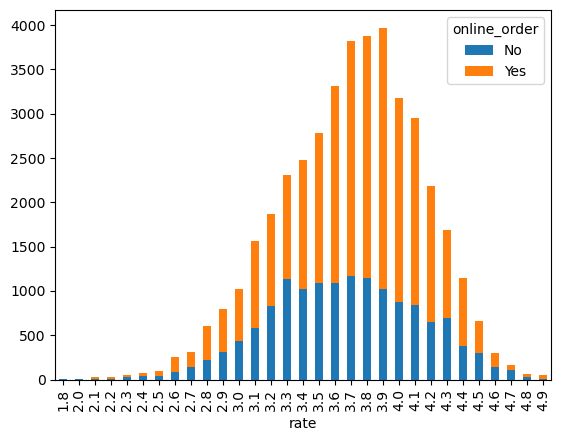

In [41]:
# A stacked bar chart is a type of data visualization that shows the composition of different categories in relation to a whole.
# Each bar in the chart is divided into segments, where each segment represents a portion of a category’s value.
# These segments are stacked on top of each other, allowing you to see both the individual parts and the total value of each category.
x.plot(kind='bar',stacked=True)

In [43]:
x.sum(axis=1).astype(float)

rate
1.8       5.0
2.0      11.0
2.1      24.0
2.2      26.0
2.3      51.0
2.4      70.0
2.5     101.0
2.6     260.0
2.7     307.0
2.8     600.0
2.9     802.0
3.0    1023.0
3.1    1561.0
3.2    1873.0
3.3    2310.0
3.4    2476.0
3.5    2784.0
3.6    3316.0
3.7    3821.0
3.8    3873.0
3.9    3972.0
4.0    3183.0
4.1    2948.0
4.2    2184.0
4.3    1693.0
4.4    1147.0
4.5     656.0
4.6     300.0
4.7     167.0
4.8      66.0
4.9      55.0
dtype: float64

In [45]:
normalized_df = x.div(x.sum(axis=1).astype(float), axis=0)

<Axes: xlabel='rate'>

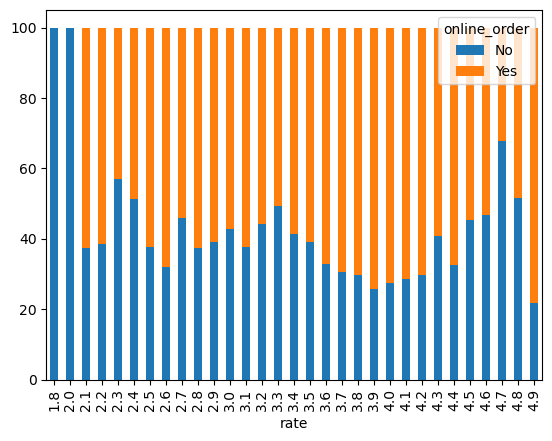

In [47]:
(normalized_df*100).plot(kind='bar',stacked=True)

Restaurants which accept online order have received more number of ratings

In [50]:
##

# Data Cleaning using Text Analysis

In [53]:
df.head()

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [55]:
df['rest_type'].isnull().sum()

227

In [57]:
data = df.dropna(subset=['rest_type'])

In [59]:
data['rest_type'].isnull().sum()

0

In [61]:
data['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', 'Dhaba', 'Quick Bites, Sweet Shop',
       'Microbrewery', 'Food Court, Quick Bites', 'Pub, Bar',
       'Casual Dining, Pub', 'Lounge, Ba

In [63]:
quick_bites = data[data['rest_type'].str.contains('Quick Bites')]

In [65]:
quick_bites.shape

(20639, 18)

In [67]:
quick_bites['reviews_list']

3        [('Rated 4.0', "RATED\n  Great food and proper...
23       [('Rated 4.0', "RATED\n  So, went here with fr...
26       [('Rated 5.0', 'RATED\n  please provide some e...
31       [('Rated 1.0', "RATED\n  Worst restaurant ever...
34       [('Rated 3.0', 'RATED\n  Not worth for the mon...
                               ...                        
51641    [('Rated 2.0', "RATED\n  Food is not upto the ...
51642                                                   []
51643                                                   []
51644                                                   []
51645    [('Rated 5.0', "RATED\n  I was randomly lookin...
Name: reviews_list, Length: 20639, dtype: object

In [69]:
quick_bites['reviews_list'] = quick_bites['reviews_list'].apply(lambda x: x.lower())

In [71]:
from nltk.corpus import RegexpTokenizer

In [73]:
tokenizer = RegexpTokenizer('[a-zA-Z]+')

In [75]:
tokenizer

RegexpTokenizer(pattern='[a-zA-Z]+', gaps=False, discard_empty=True, flags=re.UNICODE|re.MULTILINE|re.DOTALL)

In [77]:
quick_bites['reviews_list'][3]

'[(\'rated 4.0\', "rated\\n  great food and proper karnataka style full meals. been there twice and was fully satisfied.. will give 5 stars if it\'s well managed............"), (\'rated 2.0\', \'rated\\n  reached the place at 3pm on saturday. half of the items on the menu were over. what was annoying was is the food was cold. the taste was also very average. only dosa and holige were good. there were very few people in the restaurant and the service was still very slow. the waiters were all standing in one corner and talking. had to call them repeatedly.\'), (\'rated 4.0\', \'rated\\n  had been here, good food served and tasty,good place to go with freinds and family, should be first to get served well with all food. one of the good hotel there for this price.\'), (\'rated 2.0\', \'rated\\n  how can a udupi restaurant be so dirty.the floor the walls the waiters are all stained in food.why cant they clean it? the floor even had decorative colour paper every where and lot of food.now com

In [79]:
# This has been done in order to remove the special characters from the reviews list
tokenizer.tokenize(quick_bites['reviews_list'][3])

['rated',
 'rated',
 'n',
 'great',
 'food',
 'and',
 'proper',
 'karnataka',
 'style',
 'full',
 'meals',
 'been',
 'there',
 'twice',
 'and',
 'was',
 'fully',
 'satisfied',
 'will',
 'give',
 'stars',
 'if',
 'it',
 's',
 'well',
 'managed',
 'rated',
 'rated',
 'n',
 'reached',
 'the',
 'place',
 'at',
 'pm',
 'on',
 'saturday',
 'half',
 'of',
 'the',
 'items',
 'on',
 'the',
 'menu',
 'were',
 'over',
 'what',
 'was',
 'annoying',
 'was',
 'is',
 'the',
 'food',
 'was',
 'cold',
 'the',
 'taste',
 'was',
 'also',
 'very',
 'average',
 'only',
 'dosa',
 'and',
 'holige',
 'were',
 'good',
 'there',
 'were',
 'very',
 'few',
 'people',
 'in',
 'the',
 'restaurant',
 'and',
 'the',
 'service',
 'was',
 'still',
 'very',
 'slow',
 'the',
 'waiters',
 'were',
 'all',
 'standing',
 'in',
 'one',
 'corner',
 'and',
 'talking',
 'had',
 'to',
 'call',
 'them',
 'repeatedly',
 'rated',
 'rated',
 'n',
 'had',
 'been',
 'here',
 'good',
 'food',
 'served',
 'and',
 'tasty',
 'good',
 'plac

In [81]:
sample = data[0:1000]

In [83]:
reviews_tokens=sample['reviews_list'].apply(tokenizer.tokenize)

In [85]:
reviews_tokens

0       [Rated, RATED, n, A, beautiful, place, to, din...
1       [Rated, RATED, n, Had, been, here, for, dinner...
2       [Rated, RATED, n, Ambience, is, not, that, goo...
3       [Rated, RATED, n, Great, food, and, proper, Ka...
4       [Rated, RATED, n, Very, good, restaurant, in, ...
                              ...                        
995     [Rated, RATED, n, Ideal, for, quick, neighborh...
996     [Rated, RATED, n, We, ordered, for, Alankrutha...
997     [Rated, RATED, n, This, review, should, have, ...
998     [Rated, RATED, n, We, tried, Chicken, Shawarma...
1000    [Rated, RATED, n, An, authentic, Andhra, cuisi...
Name: reviews_list, Length: 1000, dtype: object

In [87]:
##

# Unigram Analysis

# A unigram analysis is a type of text analysis where individual words (or tokens) are treated as the basic unit of analysis. In this context, a "unigram" refers to a single word, and unigram analysis focuses on examining the frequency or distribution of words within a body of text.

In [91]:
# Firstly we remove the stopwords from our reviews list

In [93]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [95]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

In [97]:
stop_words

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [99]:
stop_words.extend(['rated','n','nan','x','RATED','Rated'])

In [101]:
stop_words

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [103]:
rev3 = reviews_tokens[3]
rev3

['Rated',
 'RATED',
 'n',
 'Great',
 'food',
 'and',
 'proper',
 'Karnataka',
 'style',
 'full',
 'meals',
 'Been',
 'there',
 'twice',
 'and',
 'was',
 'fully',
 'satisfied',
 'Will',
 'give',
 'stars',
 'if',
 'it',
 's',
 'well',
 'managed',
 'Rated',
 'RATED',
 'n',
 'Reached',
 'the',
 'place',
 'at',
 'pm',
 'on',
 'Saturday',
 'Half',
 'of',
 'the',
 'items',
 'on',
 'the',
 'menu',
 'were',
 'over',
 'What',
 'was',
 'annoying',
 'was',
 'is',
 'the',
 'food',
 'was',
 'cold',
 'The',
 'taste',
 'was',
 'also',
 'very',
 'average',
 'Only',
 'dosa',
 'and',
 'holige',
 'were',
 'good',
 'There',
 'were',
 'very',
 'few',
 'people',
 'in',
 'the',
 'restaurant',
 'and',
 'the',
 'service',
 'was',
 'still',
 'very',
 'slow',
 'The',
 'waiters',
 'were',
 'all',
 'standing',
 'in',
 'one',
 'corner',
 'and',
 'talking',
 'Had',
 'to',
 'call',
 'them',
 'repeatedly',
 'Rated',
 'RATED',
 'n',
 'Had',
 'been',
 'here',
 'good',
 'food',
 'served',
 'and',
 'tasty',
 'good',
 'plac

In [105]:
[token for token in rev3 if token not in stop_words]

['Great',
 'food',
 'proper',
 'Karnataka',
 'style',
 'full',
 'meals',
 'Been',
 'twice',
 'fully',
 'satisfied',
 'Will',
 'give',
 'stars',
 'well',
 'managed',
 'Reached',
 'place',
 'pm',
 'Saturday',
 'Half',
 'items',
 'menu',
 'What',
 'annoying',
 'food',
 'cold',
 'The',
 'taste',
 'also',
 'average',
 'Only',
 'dosa',
 'holige',
 'good',
 'There',
 'people',
 'restaurant',
 'service',
 'still',
 'slow',
 'The',
 'waiters',
 'standing',
 'one',
 'corner',
 'talking',
 'Had',
 'call',
 'repeatedly',
 'Had',
 'good',
 'food',
 'served',
 'tasty',
 'good',
 'place',
 'go',
 'freinds',
 'family',
 'first',
 'get',
 'served',
 'well',
 'food',
 'One',
 'good',
 'hotel',
 'price',
 'How',
 'Udupi',
 'restaurant',
 'dirty',
 'floor',
 'walls',
 'waiters',
 'stained',
 'food',
 'Why',
 'cant',
 'clean',
 'The',
 'floor',
 'even',
 'decorative',
 'colour',
 'paper',
 'every',
 'lot',
 'food',
 'Now',
 'coming',
 'taste',
 'food',
 'pretty',
 'decent',
 'chargw',
 'What',
 'upset',
 '

In [107]:
reviews_tokens_clean = reviews_tokens.apply(lambda each_review: [token for token in each_review if token not in stop_words])

In [109]:
# Reviews have been cleaned after removing the stopwords
reviews_tokens_clean

0       [A, beautiful, place, dine, The, interiors, ta...
1       [Had, dinner, family, Turned, good, choose, su...
2       [Ambience, good, enough, pocket, friendly, caf...
3       [Great, food, proper, Karnataka, style, full, ...
4       [Very, good, restaurant, neighbourhood, Buffet...
                              ...                        
995     [Ideal, quick, neighborhood, bite, Has, good, ...
996     [We, ordered, Alankrutha, Special, Biryani, Mu...
997     [This, review, posted, year, ago, better, late...
998     [We, tried, Chicken, Shawarma, Some, Panner, G...
1000    [An, authentic, Andhra, cuisine, restaurant, s...
Name: reviews_list, Length: 1000, dtype: object

In [111]:
type(reviews_tokens_clean)

pandas.core.series.Series

In [113]:
total_reviews_2D = list(reviews_tokens_clean)

In [115]:
total_reviews_1D = []

for review in total_reviews_2D:
    for word in review:
        total_reviews_1D.append(word) 

In [117]:
total_reviews_1D

['A',
 'beautiful',
 'place',
 'dine',
 'The',
 'interiors',
 'take',
 'back',
 'Mughal',
 'era',
 'The',
 'lightings',
 'perfect',
 'We',
 'went',
 'occasion',
 'Christmas',
 'limited',
 'items',
 'available',
 'But',
 'taste',
 'service',
 'compromised',
 'The',
 'complaint',
 'breads',
 'could',
 'better',
 'Would',
 'surely',
 'like',
 'come',
 'I',
 'dinner',
 'family',
 'weekday',
 'The',
 'restaurant',
 'completely',
 'empty',
 'Ambience',
 'good',
 'good',
 'old',
 'hindi',
 'music',
 'Seating',
 'arrangement',
 'good',
 'We',
 'ordered',
 'masala',
 'papad',
 'panner',
 'baby',
 'corn',
 'starters',
 'lemon',
 'corrionder',
 'soup',
 'butter',
 'roti',
 'olive',
 'chilli',
 'paratha',
 'Food',
 'fresh',
 'good',
 'service',
 'good',
 'Good',
 'family',
 'hangout',
 'nCheers',
 'Its',
 'restaurant',
 'near',
 'Banashankari',
 'BDA',
 'Me',
 'along',
 'office',
 'friends',
 'visited',
 'buffet',
 'unfortunately',
 'provide',
 'veg',
 'buffet',
 'On',
 'inquiring',
 'said',
 'pla

In [119]:
from nltk import FreqDist

In [121]:
# frequency distribution records the number of times each outcome of an experiment has occurred.
fd = FreqDist()

In [123]:
for word in total_reviews_1D:
    fd[word] = fd[word] + 1

In [125]:
fd.most_common(20)

[('good', 10260),
 ('I', 9887),
 ('food', 9105),
 ('place', 8470),
 ('The', 5433),
 ('taste', 3692),
 ('chicken', 3044),
 ('service', 2756),
 ('ordered', 2530),
 ('try', 2514),
 ('like', 2375),
 ('time', 2337),
 ('also', 2236),
 ('one', 2227),
 ('really', 2184),
 ('restaurant', 2120),
 ('It', 1991),
 ('order', 1839),
 ('nice', 1833),
 ('best', 1766)]

# Bigram Analysis , Trigram Analysis

A bigram analysis involves examining pairs of consecutive words (or characters) in a given text. 

Applications - 

1)Text Generation: Predict the next word based on the previous word.

2)Sentiment Analysis: Detect common patterns in positive or negative expressions.

A trigram analysis is an extension of bigram analysis where groups of three consecutive words (or tokens) are analyzed instead of pairs.

Applications-

1)Language Modeling: Trigrams can be used to predict the next word in a sentence based on the previous two words, improving the accuracy of text prediction models.

2)Text Classification: Understanding common three-word sequences can help with topic classification and understanding patterns in sentiment or tone.

In [129]:
from nltk import FreqDist, bigrams , trigrams

In [131]:
bi_grams = bigrams(total_reviews_1D)

In [133]:
bi_grams

<generator object bigrams at 0x000001FEE114B4C0>

In [135]:
fd_bigrams = FreqDist()

for bigram in bi_grams:
    fd_bigrams[bigram] = fd_bigrams[bigram] + 1

In [137]:
fd_bigrams.most_common(20)

[(('I', 'ordered'), 898),
 (('really', 'good'), 713),
 (('must', 'try'), 605),
 (('This', 'place'), 532),
 (('The', 'food'), 506),
 (('food', 'good'), 445),
 (('I', 'would'), 418),
 (('visit', 'place'), 408),
 (('fried', 'rice'), 403),
 (('good', 'food'), 403),
 (('ice', 'cream'), 395),
 (('good', 'place'), 390),
 (('taste', 'good'), 379),
 (('non', 'veg'), 374),
 (('also', 'good'), 366),
 (('I', 'tried'), 355),
 (('place', 'I'), 336),
 (('food', 'I'), 329),
 (('main', 'course'), 318),
 (('good', 'taste'), 306)]

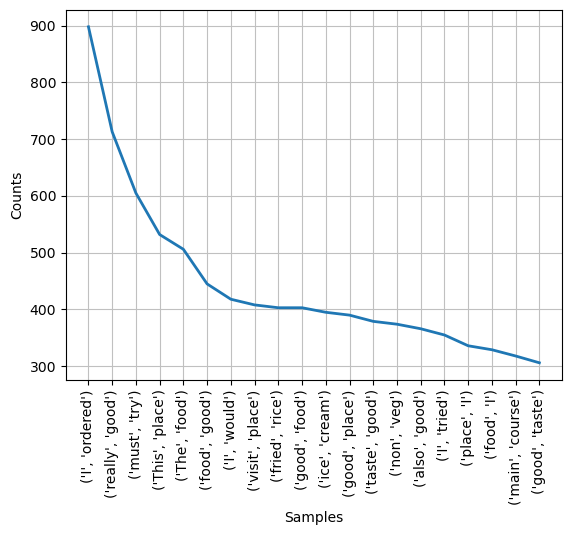

<Axes: xlabel='Samples', ylabel='Counts'>

In [139]:
fd_bigrams.plot(20)

In [141]:
tri_grams = trigrams(total_reviews_1D)

In [143]:
tri_grams

<generator object trigrams at 0x000001FEE56D5FC0>

In [145]:
fd_trigrams = FreqDist()

for trigram in tri_grams:
    fd_trigrams[trigram] = fd_trigrams[trigram] + 1

In [146]:
fd_trigrams.most_common(20)

[(('paneer', 'tikka', 'biriyani'), 88),
 (('veg', 'non', 'veg'), 80),
 (('I', 'ordered', 'food'), 75),
 (('south', 'Indian', 'food'), 74),
 (('must', 'visit', 'place'), 72),
 (('I', 'would', 'recommend'), 63),
 (('The', 'food', 'good'), 63),
 (('paneer', 'butter', 'masala'), 62),
 (('Good', 'food', 'Good'), 60),
 (('I', 'ordered', 'chicken'), 60),
 (('delious', 'good', 'need'), 58),
 (('good', 'need', 'sum'), 58),
 (('need', 'sum', 'spacy'), 58),
 (('sum', 'spacy', 'food'), 58),
 (('spacy', 'food', 'bangnda'), 58),
 (('food', 'bangnda', 'fry'), 58),
 (('bangnda', 'fry', 'received'), 58),
 (('fry', 'received', 'Nice'), 58),
 (('I', 'visited', 'place'), 57),
 (('The', 'ambience', 'good'), 56)]

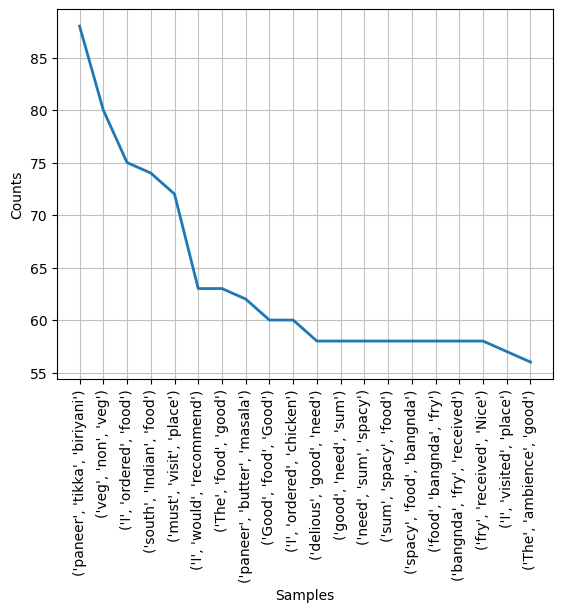

<Axes: xlabel='Samples', ylabel='Counts'>

In [149]:
fd_trigrams.plot(20)

In [151]:
# From the trigram analysis , we can say that there r a lot of chicken lovers in Bangalore.

# Extract geographical coordinates from data

In [154]:
df.head()

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [156]:
df['location'].unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', None, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan

In [158]:
len(df['location'].unique())

94

In [160]:
df['location'] = df['location'] + ", Bangalore , Karnataka , India"

In [162]:
df['location'].unique()

array(['Banashankari, Bangalore , Karnataka , India',
       'Basavanagudi, Bangalore , Karnataka , India',
       'Mysore Road, Bangalore , Karnataka , India',
       'Jayanagar, Bangalore , Karnataka , India',
       'Kumaraswamy Layout, Bangalore , Karnataka , India',
       'Rajarajeshwari Nagar, Bangalore , Karnataka , India',
       'Vijay Nagar, Bangalore , Karnataka , India',
       'Uttarahalli, Bangalore , Karnataka , India',
       'JP Nagar, Bangalore , Karnataka , India',
       'South Bangalore, Bangalore , Karnataka , India',
       'City Market, Bangalore , Karnataka , India',
       'Nagarbhavi, Bangalore , Karnataka , India',
       'Bannerghatta Road, Bangalore , Karnataka , India',
       'BTM, Bangalore , Karnataka , India',
       'Kanakapura Road, Bangalore , Karnataka , India',
       'Bommanahalli, Bangalore , Karnataka , India', nan,
       'CV Raman Nagar, Bangalore , Karnataka , India',
       'Electronic City, Bangalore , Karnataka , India',
       'HSR, Ba

In [164]:
df_copy = df.copy()

In [166]:
df_copy['location'].isnull().sum()

21

In [168]:
df_copy = df_copy.dropna(subset=['location'])

In [170]:
df_copy['location'].isnull().sum()

0

In [172]:
locations = pd.DataFrame(df_copy['location'].unique())

In [174]:
locations.columns = ['name']

In [176]:
locations

,name
0,"Banashankari, Bangalore , Karnataka , India"
1,"Basavanagudi, Bangalore , Karnataka , India"
2,"Mysore Road, Bangalore , Karnataka , India"
3,"Jayanagar, Bangalore , Karnataka , India"
4,"Kumaraswamy Layout, Bangalore , Karnataka , India"
...,...
88,"West Bangalore, Bangalore , Karnataka , India"
89,"Magadi Road, Bangalore , Karnataka , India"
90,"Yelahanka, Bangalore , Karnataka , India"
91,"Sahakara Nagar, Bangalore , Karnataka , India"


In [178]:
# Now extract your geographical coordinates

In [180]:
from geopy.geocoders import Nominatim

In [182]:
# Nominatim is a geocoder class that allows you to convert addresses into geographic coordinates (geocoding) and vice versa (reverse geocoding).
geolocator = Nominatim(user_agent='app', timeout=None)

In [184]:
lat = []
lon = []

for location in locations['name']:
    location = geolocator.geocode(location)
    if location is None:
        lat.append(np.nan)
        lon.append(np.nan)
    else:
        lat.append(location.latitude)
        lon.append(location.longitude)

In [186]:
locations['latitude'] = lat
locations['longitude'] = lon

In [188]:
locations

,name,latitude,longitude
0,"Banashankari, Bangalore , Karnataka , India",12.939333,77.553982
1,"Basavanagudi, Bangalore , Karnataka , India",12.941726,77.575502
2,"Mysore Road, Bangalore , Karnataka , India",12.960381,77.557009
3,"Jayanagar, Bangalore , Karnataka , India",12.939904,77.582638
4,"Kumaraswamy Layout, Bangalore , Karnataka , India",12.906768,77.559502
...,...,...,...
88,"West Bangalore, Bangalore , Karnataka , India",13.009652,77.553054
89,"Magadi Road, Bangalore , Karnataka , India",12.975653,77.555355
90,"Yelahanka, Bangalore , Karnataka , India",13.100698,77.596345
91,"Sahakara Nagar, Bangalore , Karnataka , India",13.062147,77.580061


In [190]:
# When geocoding fails, there are no valid latitude or longitude values to store. Using np.nan is a standard way to indicate that data is missing or undefined.
# This allows the program to keep track of locations for which no geographic coordinates could be found,
# making it easier to identify these places later for potential handling or correction.

# Building geographical heat maps

In [193]:
locations.isnull().sum()

name         0
latitude     2
longitude    2
dtype: int64

In [195]:
locations[locations['latitude'].isna()]

,name,latitude,longitude
79,"Rammurthy Nagar, Bangalore , Karnataka , India",NaN,NaN
85,"Sadashiv Nagar, Bangalore , Karnataka , India",NaN,NaN


In [197]:
locations['latitude'][79] = 13.0120218
locations['longitude'][79] = 77.6777817

In [199]:
locations['latitude'][85] = 13.010316
locations['longitude'][85] = 77.580569

In [201]:
locations.isnull().sum()

name         0
latitude     0
longitude    0
dtype: int64

In [203]:
# Access data of north indian food and make geographical heat maps

In [205]:
df['cuisines'].isnull().sum()

45

In [207]:
df = df.dropna(subset=['cuisines'])

In [209]:
north_india = df[df['cuisines'].str.contains('North Indian')]

In [211]:
north_india.shape

(21085, 18)

In [213]:
north_india.head()

,index,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,"Banashankari, Bangalore , Karnataka , India",Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,"Banashankari, Bangalore , Karnataka , India",Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,"Banashankari, Bangalore , Karnataka , India",Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,"Basavanagudi, Bangalore , Karnataka , India",Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari
5,5,https://www.zomato.com/bangalore/timepass-dinn...,"37, 5-1, 4th Floor, Bosco Court, Gandhi Bazaar...",Timepass Dinner,Yes,No,3.8,286,+91 9980040002\r\n+91 9980063005,"Basavanagudi, Bangalore , Karnataka , India",Casual Dining,"Onion Rings, Pasta, Kadhai Paneer, Salads, Sal...",North Indian,600,"[('Rated 3.0', 'RATED\n Food 3/5\nAmbience 3/...",[],Buffet,Banashankari


In [215]:
north_india_rest_count = north_india['location'].value_counts().reset_index().rename(columns={'location':'name'})

In [217]:
north_india_rest_count

,name,count
0,"BTM, Bangalore , Karnataka , India",2469
1,"HSR, Bangalore , Karnataka , India",1123
2,"Whitefield, Bangalore , Karnataka , India",1059
3,"Marathahalli, Bangalore , Karnataka , India",1038
4,"JP Nagar, Bangalore , Karnataka , India",958
...,...,...
85,"Hebbal, Bangalore , Karnataka , India",4
86,"Jakkur, Bangalore , Karnataka , India",3
87,"Central Bangalore, Bangalore , Karnataka , India",2
88,"West Bangalore, Bangalore , Karnataka , India",1


In [219]:
heatmap_df = north_india_rest_count.merge(locations, on='name', how='left')

In [221]:
heatmap_df

,name,count,latitude,longitude
0,"BTM, Bangalore , Karnataka , India",2469,12.916360,77.604733
1,"HSR, Bangalore , Karnataka , India",1123,12.900563,77.649475
2,"Whitefield, Bangalore , Karnataka , India",1059,12.969637,77.749745
3,"Marathahalli, Bangalore , Karnataka , India",1038,12.955257,77.698416
4,"JP Nagar, Bangalore , Karnataka , India",958,12.909694,77.586607
...,...,...,...,...
85,"Hebbal, Bangalore , Karnataka , India",4,13.038218,77.591900
86,"Jakkur, Bangalore , Karnataka , India",3,13.078474,77.606894
87,"Central Bangalore, Bangalore , Karnataka , India",2,12.973393,77.611247
88,"West Bangalore, Bangalore , Karnataka , India",1,13.009652,77.553054


In [223]:
import folium

In [225]:
basemap = folium.Map()

In [227]:
basemap

In [229]:
from folium.plugins import HeatMap

In [231]:
heatmap_df.columns

Index(['name', 'count', 'latitude', 'longitude'], dtype='object')

In [233]:
HeatMap(heatmap_df[['latitude', 'longitude','count']]).add_to(basemap)

In [235]:
basemap

Majority of the north indian restaurants are at city center area.

# Performing automation

In [241]:
# Defining a function that can automate all the tasks for us.

In [243]:
def get_heatmap(cuisine):
    cuisine_df = df[df['cuisines'].str.contains(cuisine)]
    
    cuisine_rest_count = cuisine_df['location'].value_counts().reset_index().rename(columns={'location':'name'})
    heatmap_df = cuisine_rest_count.merge(locations, on='name', how='left')
    print(heatmap_df.head())
    basemap = folium.Map()
    HeatMap(heatmap_df[['latitude', 'longitude','count']]).add_to(basemap)
    return basemap

In [245]:
get_heatmap('South Indian')

                                        name  count   latitude  longitude
0         BTM, Bangalore , Karnataka , India    815  12.916360  77.604733
1    JP Nagar, Bangalore , Karnataka , India    437  12.909694  77.586607
2         HSR, Bangalore , Karnataka , India    436  12.900563  77.649475
3   Jayanagar, Bangalore , Karnataka , India    416  12.939904  77.582638
4  Whitefield, Bangalore , Karnataka , India    308  12.969637  77.749745
